课后3.实践题(1)
基于例3-8,将合并后1-3月入职员工的信息按学历分组，并通过聚合求基本工资的平均值

In [139]:
import pandas as pd

pd.set_option('display.unicode.east_asian_width', True)
#读取“1～3月入职员工信息.xlsx”文件4个工作表的数据
df = pd.read_excel('1—3月入职员工信息(1).xlsx', index_col=0, sheet_name=['1月', '2月', '3月', '1月员工补充信息'])
df1_1, df1_2 = df['1月'], df['1月员工补充信息']#获取1月入职员工信息及其补充信息
df2, df3 = df['2月'], df['3月']#获取2月和3月入职员工信息
df1 = pd.merge(df1_1, df1_2)#横向合并1月入职员工信息及其补充信息
df_total = pd.concat([df1, df2, df3])#纵向连接1月、2月和3月入职员工的信息
df_total = df_total.reset_index(drop=True)#重置连续行索引
print('1～3月入职员工的信息：\n', df_total)

1～3月入职员工的信息：
      姓名    职务  基本工资     联系方式 性别  学历
0    赵文    主管      8000  152××××9852   男  硕士
1    刘武  副主管      5000  136××××8962   男  本科
2    何花    员工      5500  131××××9860   女  本科
3    李蒙  副主管      7000  150××××5820   男  硕士
4    刘珊    员工      5500  138××××2235   女  本科
5    李华    员工      5200  136××××1235   女  本科
6  张明明    员工      5500  133××××5623   男  硕士


In [140]:
powers = df_total.groupby('学历')['基本工资'].mean()
powers


学历
本科    5300.000000
硕士    6833.333333
Name: 基本工资, dtype: float64

#### 1.按照学历字段对数据进行分组

In [141]:
ables = df_total.groupby('学历')
for able in ables:
    print(able)

('本科',    姓名    职务  基本工资     联系方式 性别  学历
1  刘武  副主管      5000  136××××8962   男  本科
2  何花    员工      5500  131××××9860   女  本科
4  刘珊    员工      5500  138××××2235   女  本科
5  李华    员工      5200  136××××1235   女  本科)
('硕士',      姓名    职务  基本工资     联系方式 性别  学历
0    赵文    主管      8000  152××××9852   男  硕士
3    李蒙  副主管      7000  150××××5820   男  硕士
6  张明明    员工      5500  133××××5623   男  硕士)


#### 2.选取本科员工信息

In [142]:
ables.get_group('本科')

,姓名,职务,基本工资,联系方式,性别,学历
1,刘武,副主管,5000,136××××8962,男,本科
2,何花,员工,5500,131××××9860,女,本科
4,刘珊,员工,5500,138××××2235,女,本科
5,李华,员工,5200,136××××1235,女,本科


#### 3.统计硕士和本科员工的平均基本工资

In [143]:
powers = df_total.groupby('学历')['基本工资'].mean().round(2)
powers

学历
本科    5300.00
硕士    6833.33
Name: 基本工资, dtype: float64

#### 4.运用get_dummies()函数，实现性别数据的编码
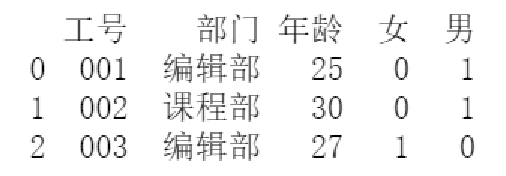

In [144]:
import pandas as pd
df=pd.DataFrame({'工号':['001','002','003'],
                 '部门':['编辑部','课程部','编辑部'],
                 '性别':['男','男','女'],
                 '年龄':['25','30','27']})
print(df)

  工号    部门 性别 年龄
0  001  编辑部   男   25
1  002  课程部   男   30
2  003  编辑部   女   27


In [145]:
pd.get_dummies(df,prefix='性别',prefix_sep='-',columns=['性别'])

,工号,部门,年龄,性别-女,性别-男
0,001,编辑部,25,False,True
1,002,课程部,30,False,True
2,003,编辑部,27,True,False


3.实践题（2）

基于例3-10，通过聚合计算每个学生的平均成绩，然后根据平均成绩判断成绩等级。
判断条件如下:平均成绩小于90则为“不合格”,处于90 (含)~110则为“中”,处于110(含) ~135则为“良”,处于135 (含) ~150则为“优”。

In [146]:
import pandas as pd
pd.set_option('display.unicode.east_asian_width', True)
df = pd.DataFrame({'班级':['一班','一班','一班','二班','二班','二班'],
                   '姓名':['刘武','王振','赵胜','赵霞','方芳','齐婷'],
                   '语文': [85, 102, 96, 126, 130, 135],
                   '数学': [100, 90, 124, 123, 140, 109],
                   '英语': [83, 110, 123, 103, 135, 90]})
print('原始数据：\n', df)

原始数据：
    班级  姓名  语文  数学  英语
0  一班  刘武    85   100    83
1  一班  王振   102    90   110
2  一班  赵胜    96   124   123
3  二班  赵霞   126   123   103
4  二班  方芳   130   140   135
5  二班  齐婷   135   109    90


#### (1)提取上述数据中的语文、数学、英语科目成绩进行组合

In [147]:
grade = df[['语文','数学','英语']]

#### （2）对数据按行求平均值

In [148]:
avg_grade = grade.agg('mean',axis=1).round(1)
df['平均成绩'] = avg_grade


In [149]:
binsvalue=[0,90,110,135,150]
labelsvalue=['不合格','中','良','优']

df['成绩等级'] = pd.cut(avg_grade,bins=binsvalue,labels=labelsvalue,right=False)
df


,班级,姓名,语文,数学,英语,平均成绩,成绩等级
0,一班,刘武,85,100,83,89.3,不合格
1,一班,王振,102,90,110,100.7,中
2,一班,赵胜,96,124,123,114.3,良
3,二班,赵霞,126,123,103,117.3,良
4,二班,方芳,130,140,135,135.0,优
5,二班,齐婷,135,109,90,111.3,良


3.实践题（3）

以下代码已完成①操作，请继续下面的操作


In [150]:
import pandas as pd
pd.set_option('display.unicode.east_asian_width', True)
df = pd.DataFrame({'year': [2019, 2020, None, 2020, 2022],
                   'month': [3, None, 6, 9, 12],
                   'day': [4, 2, 21, 2, 15]})
print('原始数据：\n', df)

原始数据：
      year  month  day
0  2019.0    3.0    4
1  2020.0    NaN    2
2     NaN    6.0   21
3  2020.0    9.0    2
4  2022.0   12.0   15


②将year列的缺失值替换为"2021",将month列的缺失值替换为"9"


In [151]:
dic = {'year':2021,'month':9}
df2 = df.fillna(dic,inplace=False)
df2

,year,month,day
0,2019.0,3.0,4
1,2020.0,9.0,2
2,2021.0,6.0,21
3,2020.0,9.0,2
4,2022.0,12.0,15



③删除所有重复的行



In [152]:
df2.drop_duplicates()

,year,month,day
0,2019.0,3.0,4
1,2020.0,9.0,2
2,2021.0,6.0,21
4,2022.0,12.0,15


④将时间信息组合成时间，并将其添加到DataFrame对象的列末

In [ ]:
# df2['time'] = df2.apply(lambda row: f"{int(row['year'])}-{int(row['month']):02d}-{int(row['day']):02d}",axis=1)
# df2
df2['time'] = pd.to_datetime(df2.astype(int).astype(str).agg('-'.join,axis=1))
df2

,year,month,day,time
0,2019.0,3.0,4,2019-03-04
1,2020.0,9.0,2,2020-09-02
2,2021.0,6.0,21,2021-06-21
3,2020.0,9.0,2,2020-09-02
4,2022.0,12.0,15,2022-12-15
